4.1 - Time Series Training

Student: Stevan Maciel Ribeiro de Souza

# Library Imports

In [143]:
import os
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
from google.colab import files
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load Data from Kaggle

In [144]:
files.upload()
path = kagglehub.dataset_download("theforcecoder/wind-power-forecasting")

Saving kaggle.json to kaggle (2).json


# Read Data and Prepare Dataset

In [145]:
df = pd.read_csv('/kaggle/input/wind-power-forecasting/Turbine_Data.csv',parse_dates=['Unnamed: 0'], index_col=['Unnamed: 0'])

df.drop_duplicates(inplace=True)  # Remove linhas duplicadas
df = df[df['ActivePower'] >= 0]   # Remove valores negativos de ActivePower
df = df.drop(columns=['WTG'])     # Remove a coluna WTG (constante)

# Correlation Analysis

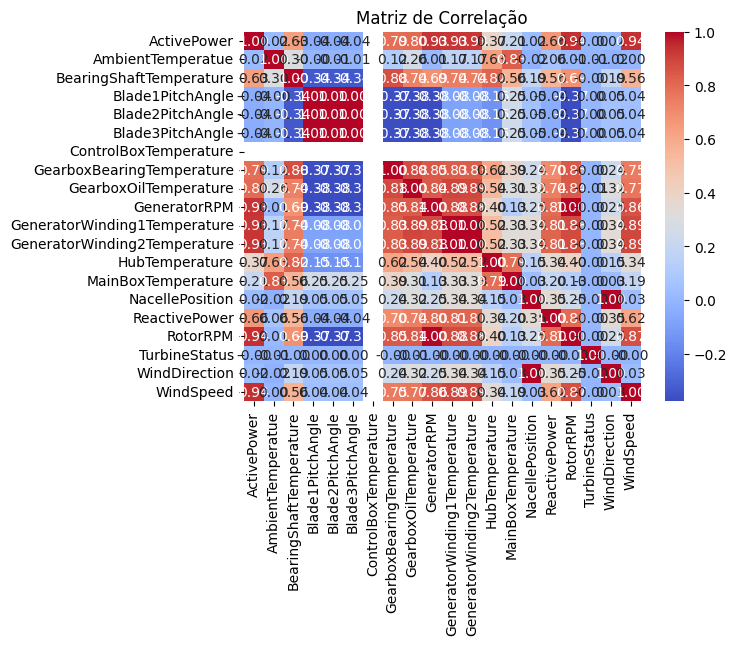

In [146]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

# Lag Feature Creation

In [147]:
for lag in range(1, 25):
    df[f'lag_{lag}'] = df['ActivePower'].shift(lag)

df = df.dropna()  # Remove linhas com valores ausentes gerados pelos lags

# Feature Selection for ActivePower Prediction

In [148]:
features = ['WindSpeed', 'RotorRPM', 'GeneratorRPM', 'GearboxOilTemperature', 'GearboxBearingTemperature'] + [f'lag_{lag}' for lag in range(1, 25)]
X = df[features]
y = df['ActivePower']

# Train/Test Split

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training and Prediction

In [150]:
model = XGBRegressor(n_estimators=200)
model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_test, y_test)],  # Usa o conjunto de teste como conjunto de validação
          verbose=False)

y_pred = model.predict(X_test)

# Evaluation

In [160]:
df_final = pd.DataFrame(data={'Reais': y_test, 'Previstos': y_pred})

# Cálculo do erro quadrático médio (MSE) e raiz do erro quadrático médio (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 982.58
Root Mean Squared Error (RMSE): 31.35


# Results Visualization

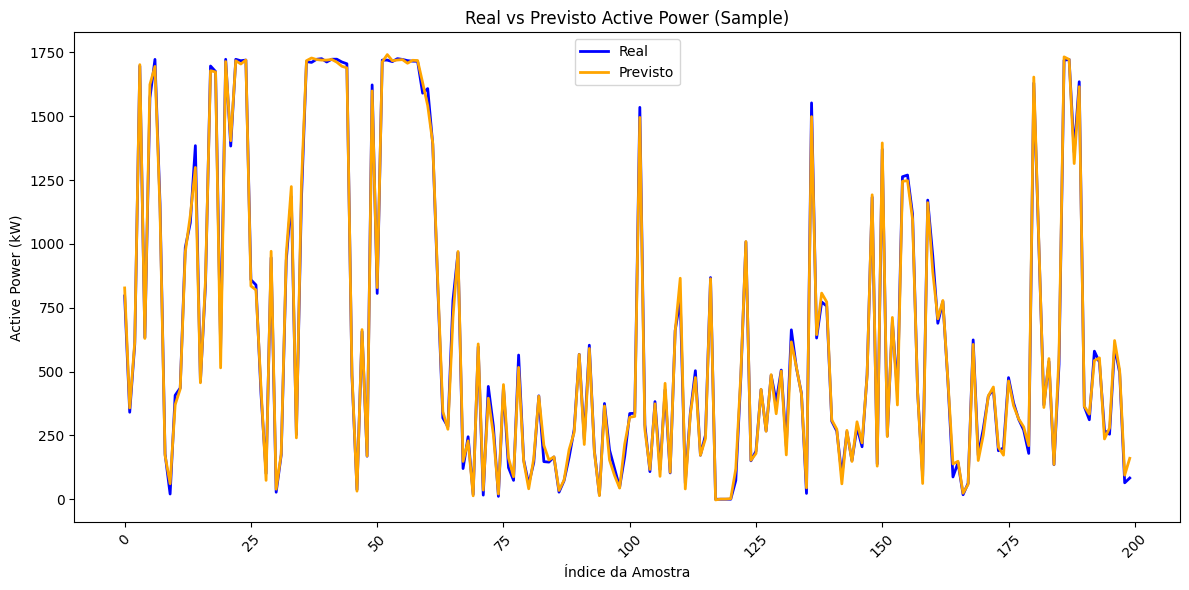

In [162]:
# Selecionar uma amostra de 200 pontos para plotar
df_sample = df_final.sample(n=200, random_state=42).sort_index()

plt.figure(figsize=(12, 6))
plt.plot(range(len(df_sample)), df_sample['Reais'], label='Real', color='blue', linewidth=2)
plt.plot(range(len(df_sample)), df_sample['Previstos'], label='Previsto', color='orange', linewidth=2)

plt.title('Real vs Previsto Active Power (Sample)')
plt.xlabel('Índice da Amostra')
plt.ylabel('Active Power (kW)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()